<a href="https://colab.research.google.com/github/Samar125/mt_sem/blob/final_sem_DR/mtech_sem_proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_covtype
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import time
import seaborn as sns
from scipy.linalg import eigh
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

In [ ]:
# Setting random seed for reproducibility
np.random.seed(42)

In [ ]:
# Loading the Forest Cover Type dataset
print("Loading dataset...")
data = fetch_covtype()
X = data.data
y = data.target
feature_names = [f'feature_{i}' for i in range(X.shape[1])]
print(f"Dataset loaded: {X.shape[0]} samples with {X.shape[1]} features")

Loading dataset...
Dataset loaded: 581012 samples with 54 features


**Data preprocessing**

In [ ]:
# Standardizing the features
print("Preprocessing data...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Preprocessing data...


In [ ]:
# Standardizing the features
print("Preprocessing data...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Preprocessing data...


In [ ]:
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape}, Testing set: {X_test.shape}")

Training set: (464809, 54), Testing set: (116203, 54)


**Traditional PCA Implementation**

**First, let's implement traditional PCA using eigendecomposition:**

In [ ]:
def traditional_pca(X, n_components):
 # Compute the covariance matrix
    start_time = time.time()
    cov_matrix = np.cov(X.T)


    # Compute eigenvalues and eigenvectors of the covariance matrix
    eigenvalues, eigenvectors = eigh(cov_matrix)


    # Sort eigenvalues and corresponding eigenvectors in descending order
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]


    # Select the top n_components eigenvectors
    components = eigenvectors[:, :n_components]
    explained_variance = eigenvalues[:n_components]


    # Project the data
    X_reduced = np.dot(X, components)


    computation_time = time.time() - start_time
    return X_reduced, components, explained_variance, computation_time


    # Apply traditional PCA
print("Applying traditional PCA...")
n_components = 10
X_pca_trad, components_trad, exp_var_trad, time_trad = traditional_pca(X_scaled, n_components)
print(f"Traditional PCA completed in {time_trad:.4f} seconds")

Applying traditional PCA...
Traditional PCA completed in 0.5013 seconds


**Linear Optimization Approach to PCA**

**Now, let's implement our proposed linear optimization approach:**

In [ ]:
def linear_optimization_pca(X, n_components):
    """
    Perform PCA using linear optimization approach.

    Parameters:
    -----------
    X : array-like, shape (n_samples, n_features)
        The input data
    n_components : int
        Number of components to keep

    Returns:
    --------
    X_reduced : array-like, shape (n_samples, n_components)
        Projected data
    components : array-like, shape (n_components, n_features)
        Principal components
    explained_variance : array-like, shape (n_components,)
        Explained variance by each component
    """
    from scipy.optimize import minimize

    n_samples, n_features = X.shape
    components = np.zeros((n_features, n_components))
    X_centered = X - np.mean(X, axis=0)

    start_time = time.time()

    # Compute components one by one
    for j in range(n_components):
        # Define objective function (negative variance to convert maximization to minimization)

        def objective(w):
            # Compute projections
            projections = np.dot(X_centered, w)
            # Return negative variance (for minimization)
            return -np.var(projections)

         # Define constraint for unit norm
        def constraint_unit_norm(w):
            return np.sum(w**2) - 1

        constraints = [{'type': 'eq', 'fun': constraint_unit_norm}]

         #Add orthogonality constraints for subsequent components
        if j > 0:
            for k in range(j):
                def constraint_orthogonality(w, k=k):
                    return np.abs(np.dot(w, components[:, k]))

                constraints.append({'type': 'eq', 'fun': constraint_orthogonality})

         # Initial guess (random vector)
        w0 = np.random.randn(n_features)
        w0 = w0 / np.linalg.norm(w0)

        # Solve the optimization problem
        result = minimize(objective, w0, method='SLSQP', constraints=constraints)

        if not result.success:
            print(f"Optimization for component {j+1} failed: {result.message}")

        # Store the component
        components[:, j] = result.x

        # Compute projections
    X_reduced = np.dot(X_centered, components)

    # Compute explained variance
    explained_variance = np.var(X_reduced, axis=0)

    computation_time = time.time() - start_time
    return X_reduced, components, explained_variance, computation_time

 # Apply our proposed linear optimization PCA approach
print("Applying linear optimization PCA...")
X_pca_opt, components_opt, exp_var_opt, time_opt = linear_optimization_pca(X_scaled[:5000], n_components)
print(f"Linear optimization PCA completed in {time_opt:.4f} seconds")

Applying linear optimization PCA...
Optimization for component 8 failed: Iteration limit reached
Optimization for component 9 failed: Iteration limit reached
Optimization for component 10 failed: Iteration limit reached
Linear optimization PCA completed in 12.4415 seconds


**Comparing Results**

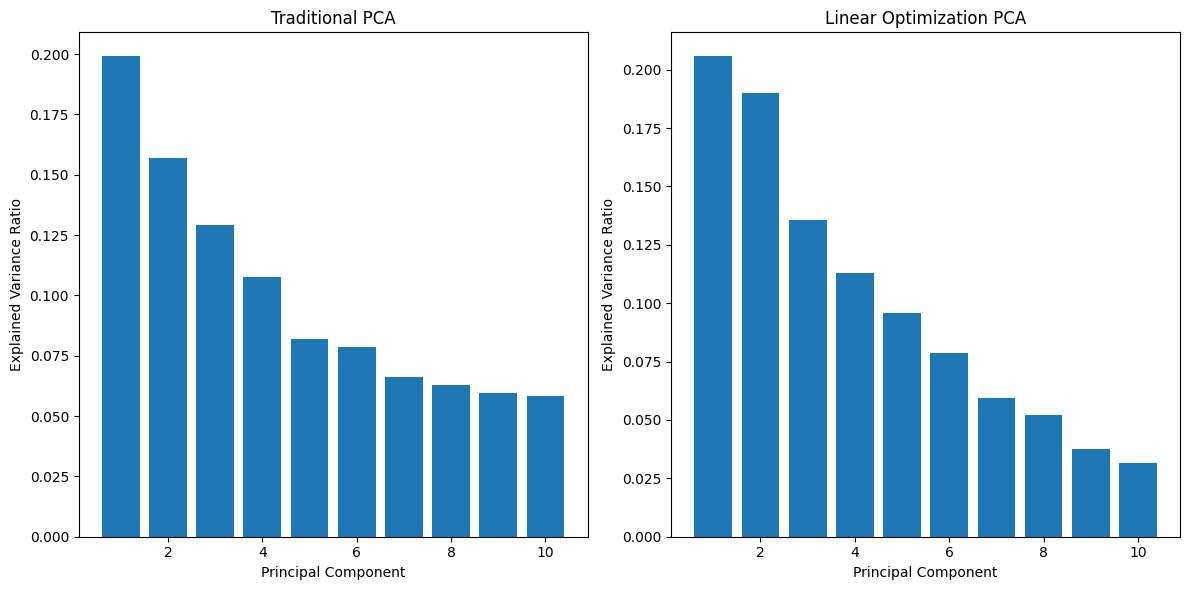

Computation time comparison:
Traditional PCA: 0.5013 seconds
Linear optimization PCA: 12.4415 seconds


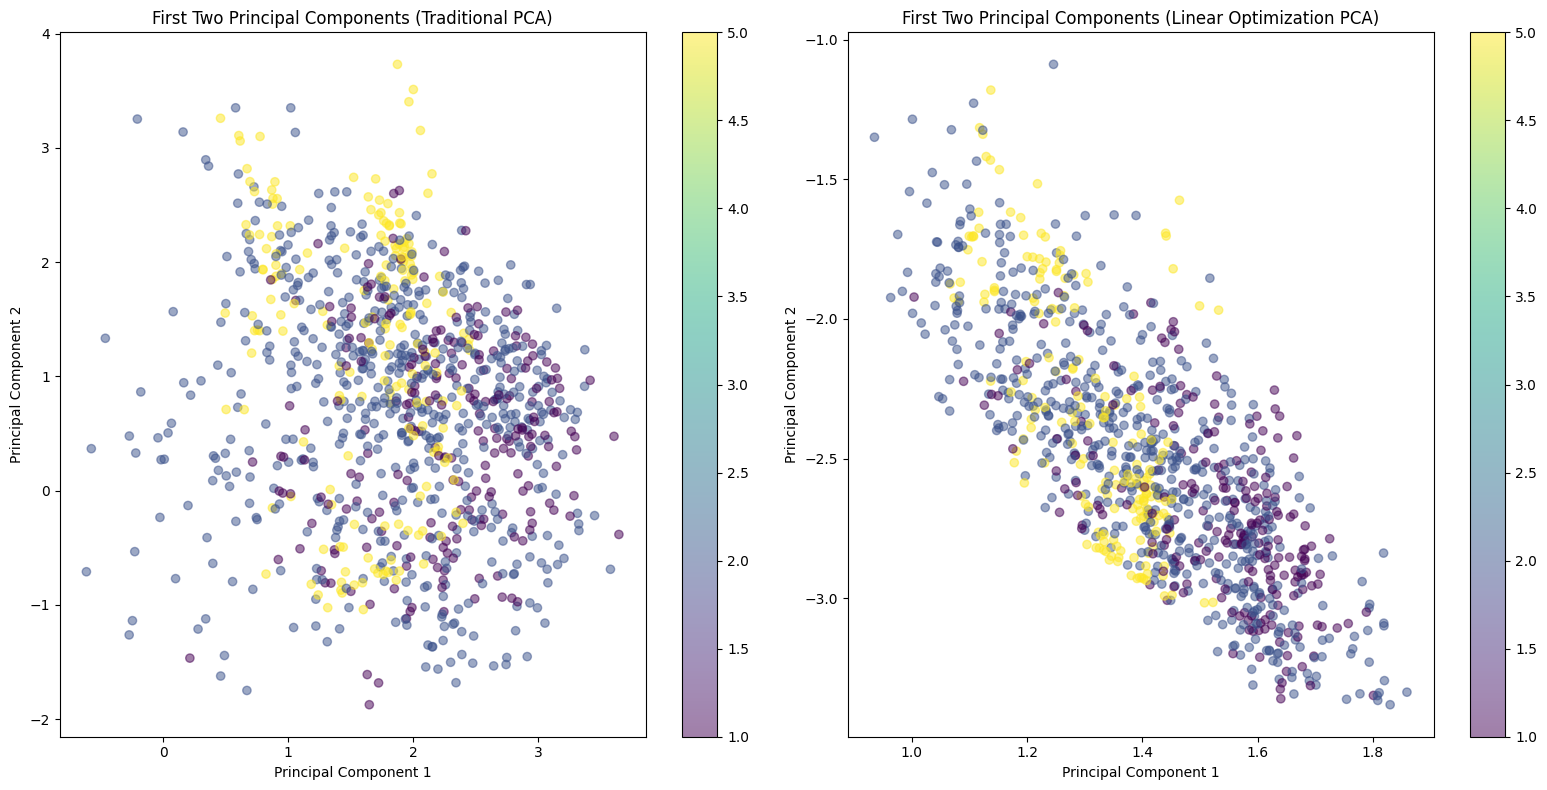

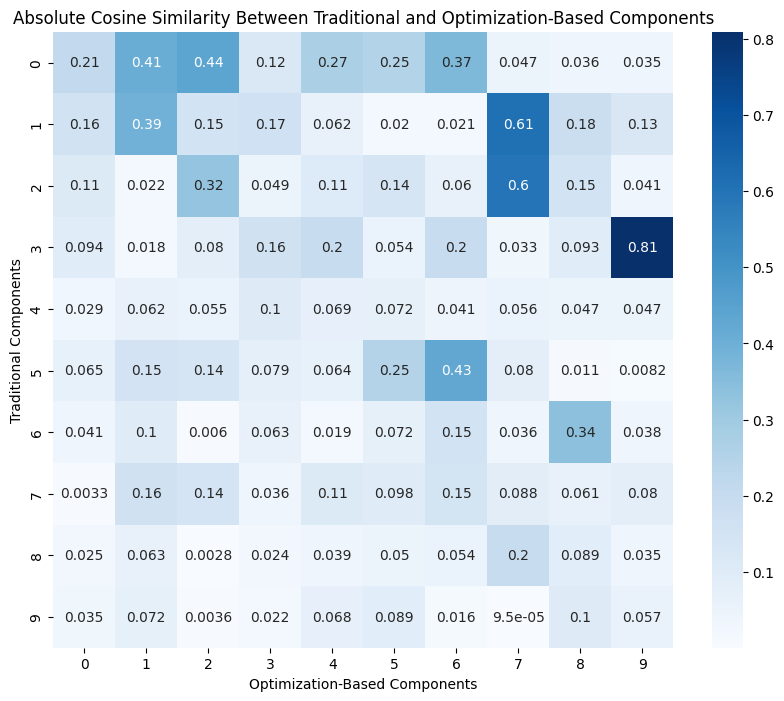

In [ ]:
# Compute explained variance ratio
explained_variance_ratio_trad = exp_var_trad / np.sum(exp_var_trad)
explained_variance_ratio_opt = exp_var_opt / np.sum(exp_var_opt)

# Plot explained variance
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.bar(range(1, n_components + 1), explained_variance_ratio_trad)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Traditional PCA')

plt.subplot(1, 2, 2)
plt.bar(range(1, n_components + 1), explained_variance_ratio_opt)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Linear Optimization PCA')

plt.tight_layout()
plt.savefig('explained_variance_comparison.png')
plt.show()

# Compare computation time
print(f"Computation time comparison:")
print(f"Traditional PCA: {time_trad:.4f} seconds")
print(f"Linear optimization PCA: {time_opt:.4f} seconds")

# Visualize the first two principal components
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca_trad[:1000, 0], X_pca_trad[:1000, 1], c=y[:1000], cmap='viridis', alpha=0.5)
plt.colorbar(scatter)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('First Two Principal Components (Traditional PCA)')

plt.subplot(1, 2, 2)
scatter = plt.scatter(X_pca_opt[:1000, 0], X_pca_opt[:1000, 1], c=y[:1000], cmap='viridis', alpha=0.5)
plt.colorbar(scatter)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('First Two Principal Components (Linear Optimization PCA)')

plt.tight_layout()
plt.savefig('pca_visualization_comparison.png')
plt.show()

# Compare the resulting components
similarity = np.abs(np.dot(components_trad.T, components_opt))
plt.figure(figsize=(10, 8))
sns.heatmap(similarity, annot=True, cmap='Blues')
plt.title('Absolute Cosine Similarity Between Traditional and Optimization-Based Components')
plt.xlabel('Optimization-Based Components')
plt.ylabel('Traditional Components')
plt.savefig('component_similarity.png')
plt.show()


**Evaluating Classification Performance**

Evaluating classification performance...
Optimization for component 4 failed: Iteration limit reached
Optimization for component 5 failed: Iteration limit reached
Optimization for component 4 failed: Iteration limit reached
Optimization for component 6 failed: Iteration limit reached
Optimization for component 5 failed: Iteration limit reached
Optimization for component 6 failed: Iteration limit reached
Optimization for component 7 failed: Iteration limit reached
Optimization for component 5 failed: Iteration limit reached
Optimization for component 6 failed: Iteration limit reached
Optimization for component 8 failed: Iteration limit reached
Optimization for component 7 failed: Iteration limit reached
Optimization for component 8 failed: Iteration limit reached
Optimization for component 9 failed: Iteration limit reached
Optimization for component 4 failed: Iteration limit reached
Optimization for component 5 failed: Iteration limit reached
Optimization for component 6 failed: Iterati

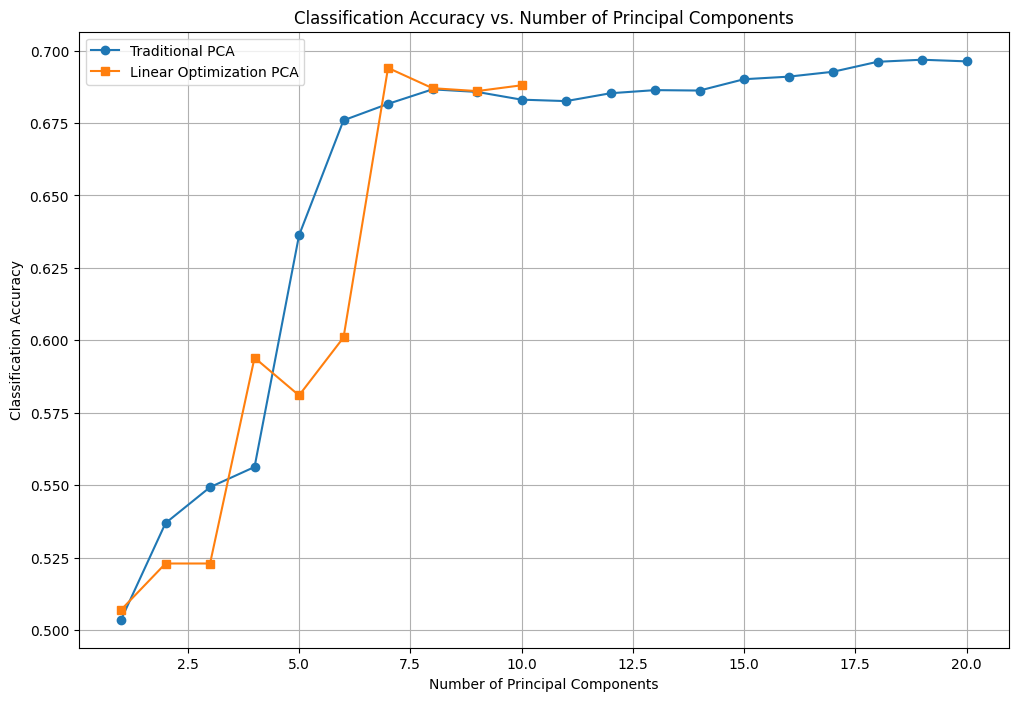


Results Summary:
Dataset: Forest Cover Type with 581012 samples and 54 features
Optimal number of components (Traditional PCA): 19
Best accuracy (Traditional PCA): 0.6968
Optimal number of components (Linear Optimization PCA): 7
Best accuracy (Linear Optimization PCA): 0.6940


In [ ]:
# Function to evaluate classification performance with different numbers of components
def evaluate_classification(X_train, X_test, y_train, y_test, max_components=20):
    accuracies_trad = []
    accuracies_opt = []
    components_range = range(1, max_components + 1)

    for n_comp in components_range:
        # Traditional PCA
        pca_trad = PCA(n_components=n_comp)
        X_train_trad = pca_trad.fit_transform(X_train)
        X_test_trad = pca_trad.transform(X_test)

        clf_trad = LogisticRegression(max_iter=1000, random_state=42)
        clf_trad.fit(X_train_trad, y_train)
        y_pred_trad = clf_trad.predict(X_test_trad)
        acc_trad = accuracy_score(y_test, y_pred_trad)
        accuracies_trad.append(acc_trad)

        # Linear Optimization PCA (using subset for demonstration)
        if n_comp <= 10:  # Limit to 10 components for optimization approach due to computation time
            X_train_subset = X_train[:5000]
            y_train_subset = y_train[:5000]
            X_test_subset = X_test[:1000]
            y_test_subset = y_test[:1000]

            X_reduced, components, _, _ = linear_optimization_pca(X_train_subset, n_comp)
            X_test_reduced = np.dot(X_test_subset - np.mean(X_train_subset, axis=0), components)

            clf_opt = LogisticRegression(max_iter=1000, random_state=42)
            clf_opt.fit(X_reduced, y_train_subset)
            y_pred_opt = clf_opt.predict(X_test_reduced)
            acc_opt = accuracy_score(y_test_subset, y_pred_opt)
            accuracies_opt.append(acc_opt)

    return components_range, accuracies_trad, accuracies_opt

# Evaluate classification performance
print("Evaluating classification performance...")
components_range, accuracies_trad, accuracies_opt = evaluate_classification(X_train, X_test, y_train, y_test, max_components=20)

# Plot classification accuracy
plt.figure(figsize=(12, 8))
plt.plot(components_range, accuracies_trad, marker='o', label='Traditional PCA')
plt.plot(components_range[:len(accuracies_opt)], accuracies_opt, marker='s', label='Linear Optimization PCA')
plt.xlabel('Number of Principal Components')
plt.ylabel('Classification Accuracy')
plt.title('Classification Accuracy vs. Number of Principal Components')
plt.legend()
plt.grid(True)
plt.savefig('classification_accuracy.png')
plt.show()

# Summary of results
print("\nResults Summary:")
print(f"Dataset: Forest Cover Type with {X.shape[0]} samples and {X.shape[1]} features")
print(f"Optimal number of components (Traditional PCA): {np.argmax(accuracies_trad) + 1}")
print(f"Best accuracy (Traditional PCA): {np.max(accuracies_trad):.4f}")
if accuracies_opt:
    print(f"Optimal number of components (Linear Optimization PCA): {np.argmax(accuracies_opt) + 1}")
    print(f"Best accuracy (Linear Optimization PCA): {np.max(accuracies_opt):.4f}")
